In [3]:
%pip install pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.8 MB 14.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 18.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 17.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ------------ --------------------------- 3.9/12.7 MB 20.3 MB/s eta 0:00:01
   ------------------------ --------------- 7.9/12.7 MB 18.9 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.7 MB 20.7 MB/s eta 0:00:01
   ---------------------------------------- 12.7/12.7 MB 19.6 MB/s  0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------- -------------------- 4.7/9.5 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 23.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 22.2 MB/s  0:00:00
   ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Import core data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for cleaner charts
sns.set_theme(style="whitegrid")

# Load the training dataset
# Using '../data/' because this notebook is inside the 'notebooks' folder
df_train = pd.read_csv('../data/application_train.csv')

# Display the size of the dataset and the first 5 rows
print(f"Dataset Shape: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
display(df_train.head())

Dataset Shape: 307511 rows, 122 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Target Variable Distribution:
          Count  Percentage (%)
TARGET                        
0       282686       91.927118
1        24825        8.072882


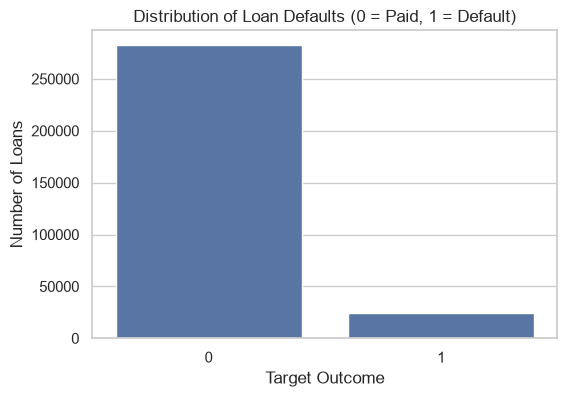

In [5]:
# Count the occurrences of each class
target_counts = df_train['TARGET'].value_counts()
target_percentages = df_train['TARGET'].value_counts(normalize=True) * 100

# Create a summary dataframe
imbalance_summary = pd.DataFrame({
    'Count': target_counts, 
    'Percentage (%)': target_percentages
})
print("Target Variable Distribution:\n", imbalance_summary)

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='TARGET')
plt.title('Distribution of Loan Defaults (0 = Paid, 1 = Default)')
plt.ylabel('Number of Loans')
plt.xlabel('Target Outcome')
plt.show()

In [6]:
# Calculate the percentage of missing values for each column
missing_data = df_train.isnull().sum()
missing_percent = (missing_data / len(df_train)) * 100

# Create a dataframe to view columns with the most missing data
missing_df = pd.DataFrame({
    'Missing Values': missing_data, 
    'Percentage (%)': missing_percent
})

# Filter to show only columns that are actually missing data, sorted highest to lowest
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print(f"Total columns with missing values: {len(missing_df)}")
display(missing_df.head(10)) # Look at the top 10 worst columns

Total columns with missing values: 67


,Missing Values,Percentage (%)
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
